# Comparative Analysis: Baseline vs Temporal Graph-Enhanced AI-Gated Markowitz

This notebook provides a **head-to-head comparison** between:

## Strategy A: Baseline AI-Gated Markowitz
- Random Forest classifier with traditional features (volatility, momentum)
- Standard Markowitz portfolio optimization
- AI-based market timing (bull/bear gating)

## Strategy B: Temporal Graph-Enhanced AI-Gated Markowitz
- Enhanced Random Forest with network features
- Network-adjusted Markowitz optimization (centrality-weighted)
- Dynamic correlation analysis via temporal graphs
- Market regime detection through network topology

## Comparison Metrics:
1. **Returns**: Total return, annualized return
2. **Risk**: Volatility, max drawdown, Sharpe ratio
3. **Consistency**: Win rate, monthly returns
4. **ML Performance**: Prediction accuracy, feature importance
5. **Network Insights**: Centrality evolution, density dynamics

In [1]:
# Core Libraries
import pandas as pd
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Network Analysis
import networkx as nx

# Visualization
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('✅ All libraries imported successfully!')
print(f'Pandas: {pd.__version__} | NumPy: {np.__version__} | NetworkX: {nx.__version__}')

✅ All libraries imported successfully!
Pandas: 2.3.3 | NumPy: 2.3.5 | NetworkX: 3.5


In [2]:
# Load Multi-Asset Cryptocurrency Data
print("Loading data...\n")
file_path = 'real_crypto_data.csv'
df = pd.read_csv(file_path, parse_dates=['Date'], index_col='Date')

print(f"Assets: {df.columns.tolist()}")
print(f"Total Data Points: {len(df)}")
print(f"Date Range: {df.index.min().date()} to {df.index.max().date()}")

# Calculate market features
returns_df = df.pct_change().fillna(0)
volatility_df = returns_df.rolling(window=20).std().fillna(0)
sma50 = df.rolling(window=50).mean()
momentum_df = (df / sma50 - 1).fillna(0)

assets = df.columns.tolist()
n_assets = len(assets)

# Train/Test Split
train_mask = (df.index.year == 2023) | (df.index.year == 2024)
test_mask = (df.index.year == 2025)

train_df = df[train_mask]
test_df = df[test_mask]
train_returns = returns_df[train_mask]
test_returns = returns_df[test_mask]

print(f"\nTraining Period (2023-2024): {len(train_df)} days")
print(f"Testing Period (2025): {len(test_df)} days")

Loading data...

Assets: ['BCH', 'BTC', 'ETH', 'LTC', 'XRP']
Total Data Points: 1096
Date Range: 2023-01-01 to 2025-12-31

Training Period (2023-2024): 731 days
Testing Period (2025): 365 days


---
# STRATEGY A: Baseline AI-Gated Markowitz
---

In [3]:
# Train Baseline Classifier (Traditional Features Only)
print("="*60)
print("STRATEGY A: BASELINE AI-GATED MARKOWITZ")
print("="*60)
print("\nTraining baseline classifier...\n")

# Prepare features
market_ret = returns_df.mean(axis=1)
feat_baseline = pd.DataFrame(index=returns_df.index)
feat_baseline['Vol_20'] = market_ret.rolling(20).std()
feat_baseline['Mom_20'] = market_ret.rolling(20).mean()
feat_baseline['Target'] = (market_ret.shift(-1) > 0).astype(int)
feat_baseline = feat_baseline.dropna()

# Split features
train_mask_rf = (feat_baseline.index.year == 2023) | (feat_baseline.index.year == 2024)
test_mask_rf = (feat_baseline.index.year == 2025)

X_train_baseline = feat_baseline.loc[train_mask_rf, ['Vol_20', 'Mom_20']]
y_train_baseline = feat_baseline.loc[train_mask_rf, 'Target']
X_test_baseline = feat_baseline.loc[test_mask_rf, ['Vol_20', 'Mom_20']]
y_test_baseline = feat_baseline.loc[test_mask_rf, 'Target']

# Train classifier
clf_baseline = RandomForestClassifier(
    n_estimators=100,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)
clf_baseline.fit(X_train_baseline, y_train_baseline)

# Predictions
baseline_train_pred = clf_baseline.predict(X_train_baseline)
baseline_test_pred = clf_baseline.predict(X_test_baseline)
baseline_probs = clf_baseline.predict_proba(X_test_baseline)[:, 1]

baseline_train_acc = accuracy_score(y_train_baseline, baseline_train_pred)
baseline_test_acc = accuracy_score(y_test_baseline, baseline_test_pred)

print(f"Training Accuracy: {baseline_train_acc:.3f}")
print(f"Testing Accuracy: {baseline_test_acc:.3f}")
print(f"Features Used: {X_train_baseline.columns.tolist()}")

STRATEGY A: BASELINE AI-GATED MARKOWITZ

Training baseline classifier...

Training Accuracy: 0.885
Testing Accuracy: 0.501
Features Used: ['Vol_20', 'Mom_20']


In [4]:
# Markowitz Optimization Function
def optimize_markowitz(returns_window, cov_matrix):
    n = returns_window.shape[1]
    if n == 0:
        return np.array([])
    
    def neg_sharpe(weights):
        portfolio_return = np.sum(returns_window.mean() * weights) * 252
        portfolio_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights))) * np.sqrt(252)
        return -(portfolio_return / portfolio_vol) if portfolio_vol > 0 else 0
    
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(n))
    init_guess = n * [1. / n]
    
    try:
        res = minimize(neg_sharpe, init_guess, method='SLSQP', 
                      bounds=bounds, constraints=constraints)
        return res.x
    except:
        return np.array(init_guess)


# Backtest Baseline Strategy
print("\nRunning baseline backtest...\n")

initial_capital = 100.0
lookback = 50
baseline_portfolio = []
baseline_value = initial_capital

# Create probability series aligned with test dates
baseline_prob_series = pd.Series(baseline_probs, index=X_test_baseline.index)

for step in range(len(test_df) - 1):
    current_date = test_df.index[step]
    
    if current_date not in baseline_prob_series.index:
        continue
    
    current_prices = test_df.iloc[step].values
    next_returns = test_returns.iloc[step + 1].values
    
    # Markowitz weights
    glob_idx = returns_df.index.get_loc(current_date)
    if glob_idx >= lookback:
        window_ret = returns_df.iloc[glob_idx-lookback:glob_idx]
        cov_mat = window_ret.cov().values
        mw_weights = optimize_markowitz(window_ret, cov_mat)
    else:
        mw_weights = np.ones(n_assets) / n_assets
    
    # AI Gating
    bull_prob = baseline_prob_series.loc[current_date]
    
    if bull_prob > 0.52:
        ai_weights = mw_weights
    elif bull_prob < 0.48:
        ai_weights = np.zeros(n_assets)
    else:
        ai_weights = 0.5 * mw_weights
    
    # Calculate return
    portfolio_return = np.sum(ai_weights * next_returns)
    baseline_value = baseline_value * (1 + portfolio_return)
    
    baseline_portfolio.append({
        'Date': current_date,
        'Value': baseline_value,
        'Bull_Prob': bull_prob * 100
    })

baseline_df = pd.DataFrame(baseline_portfolio)
baseline_return = ((baseline_value - initial_capital) / initial_capital) * 100

print(f"Final Value: ${baseline_value:.2f}")
print(f"Total Return: {baseline_return:.2f}%")
print(f"Number of Trades: {len(baseline_df)}")


Running baseline backtest...

Final Value: $190.93
Total Return: 90.93%
Number of Trades: 364


---
# STRATEGY B: Temporal Graph-Enhanced AI-Gated Markowitz
---

In [5]:
# Temporal Graph Functions
def build_correlation_graph(returns_window, threshold=0.5):
    """Build weighted correlation graph."""
    corr_matrix = returns_window.corr()
    G = nx.Graph()
    
    for asset in corr_matrix.columns:
        G.add_node(asset)
    
    for i, asset1 in enumerate(corr_matrix.columns):
        for j, asset2 in enumerate(corr_matrix.columns):
            if i < j:
                corr_value = corr_matrix.iloc[i, j]
                if abs(corr_value) > threshold:
                    G.add_edge(asset1, asset2, 
                              weight=abs(corr_value),
                              correlation=corr_value)
    return G


def extract_network_features(G, assets):
    """Extract network metrics."""
    features = {}
    
    try:
        degree_cent = nx.degree_centrality(G)
        betweenness_cent = nx.betweenness_centrality(G)
        
        try:
            eigenvector_cent = nx.eigenvector_centrality(G, max_iter=1000)
        except:
            eigenvector_cent = {asset: 0 for asset in assets}
        
        clustering = nx.clustering(G)
        
        for asset in assets:
            features[asset] = {
                'degree_centrality': degree_cent.get(asset, 0),
                'betweenness_centrality': betweenness_cent.get(asset, 0),
                'eigenvector_centrality': eigenvector_cent.get(asset, 0),
                'clustering_coef': clustering.get(asset, 0)
            }
        
        features['global'] = {
            'density': nx.density(G),
            'avg_clustering': nx.average_clustering(G),
            'num_edges': G.number_of_edges()
        }
    except:
        features = {asset: {'degree_centrality': 0, 'betweenness_centrality': 0,
                           'eigenvector_centrality': 0, 'clustering_coef': 0} 
                   for asset in assets}
        features['global'] = {'density': 0, 'avg_clustering': 0, 'num_edges': 0}
    
    return features


def build_temporal_graphs(returns_df, window=30, threshold=0.5):
    """Build temporal graph sequence."""
    temporal_graphs = []
    assets = returns_df.columns.tolist()
    
    for i in range(window, len(returns_df)):
        window_data = returns_df.iloc[i-window:i]
        current_date = returns_df.index[i]
        
        G = build_correlation_graph(window_data, threshold)
        features = extract_network_features(G, assets)
        
        temporal_graphs.append({
            'date': current_date,
            'graph': G,
            'features': features
        })
    
    return temporal_graphs


print('✅ Temporal graph functions defined!')

✅ Temporal graph functions defined!


In [6]:
# Build Temporal Graphs
print("="*60)
print("STRATEGY B: TEMPORAL GRAPH-ENHANCED")
print("="*60)
print("\nBuilding temporal graphs (this may take a moment...)\n")

window_size = 30
correlation_threshold = 0.5

train_graphs = build_temporal_graphs(train_returns, window=window_size, 
                                     threshold=correlation_threshold)
test_graphs = build_temporal_graphs(test_returns, window=window_size, 
                                    threshold=correlation_threshold)

print(f"✅ Built {len(train_graphs)} training graphs")
print(f"✅ Built {len(test_graphs)} testing graphs")

STRATEGY B: TEMPORAL GRAPH-ENHANCED

Building temporal graphs (this may take a moment...)

✅ Built 701 training graphs
✅ Built 335 testing graphs


In [7]:
# Prepare Enhanced Features
def prepare_enhanced_features(returns_df, temporal_graphs):
    """Combine traditional + network features."""
    features_list = []
    dates = []
    
    for graph_data in temporal_graphs:
        date = graph_data['date']
        network_features = graph_data['features']
        
        if date not in returns_df.index:
            continue
        
        idx = returns_df.index.get_loc(date)
        market_ret = returns_df.iloc[idx].mean()
        vol_20 = returns_df.iloc[max(0, idx-20):idx].std().mean()
        mom_20 = returns_df.iloc[max(0, idx-20):idx].mean().mean()
        
        global_features = network_features['global']
        avg_degree_cent = np.mean([network_features[asset]['degree_centrality'] 
                                   for asset in assets])
        avg_between_cent = np.mean([network_features[asset]['betweenness_centrality'] 
                                    for asset in assets])
        
        feature_vector = [
            vol_20, mom_20,
            global_features['density'],
            global_features['avg_clustering'],
            global_features['num_edges'],
            avg_degree_cent,
            avg_between_cent
        ]
        
        features_list.append(feature_vector)
        dates.append(date)
    
    feature_names = ['Vol_20', 'Mom_20', 'Network_Density', 'Network_Clustering',
                    'Num_Edges', 'Avg_Degree_Cent', 'Avg_Between_Cent']
    
    X = pd.DataFrame(features_list, columns=feature_names, index=dates)
    
    y = pd.Series(index=dates, dtype=int)
    for i, date in enumerate(dates):
        if i < len(dates) - 1:
            next_date = dates[i + 1]
            next_ret = returns_df.loc[next_date].mean()
            y.loc[date] = 1 if next_ret > 0 else 0
        else:
            y.loc[date] = 0
    
    return X, y


print("Preparing enhanced features...")
X_train_enhanced, y_train_enhanced = prepare_enhanced_features(train_returns, train_graphs)
X_test_enhanced, y_test_enhanced = prepare_enhanced_features(test_returns, test_graphs)

print(f"\nTraining set: {X_train_enhanced.shape}")
print(f"Testing set: {X_test_enhanced.shape}")
print(f"Features: {X_train_enhanced.columns.tolist()}")

Preparing enhanced features...

Training set: (701, 7)
Testing set: (335, 7)
Features: ['Vol_20', 'Mom_20', 'Network_Density', 'Network_Clustering', 'Num_Edges', 'Avg_Degree_Cent', 'Avg_Between_Cent']


In [8]:
# Train Enhanced Classifier
print("\nTraining enhanced classifier...\n")

clf_enhanced = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)

clf_enhanced.fit(X_train_enhanced, y_train_enhanced)

enhanced_train_pred = clf_enhanced.predict(X_train_enhanced)
enhanced_test_pred = clf_enhanced.predict(X_test_enhanced)
enhanced_probs = clf_enhanced.predict_proba(X_test_enhanced)[:, 1]

enhanced_train_acc = accuracy_score(y_train_enhanced, enhanced_train_pred)
enhanced_test_acc = accuracy_score(y_test_enhanced, enhanced_test_pred)

print(f"Training Accuracy: {enhanced_train_acc:.3f}")
print(f"Testing Accuracy: {enhanced_test_acc:.3f}")

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': X_train_enhanced.columns,
    'Importance': clf_enhanced.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 5 Features:")
print(feature_importance.head().to_string(index=False))


Training enhanced classifier...

Training Accuracy: 0.826
Testing Accuracy: 0.513

Top 5 Features:
           Feature  Importance
            Vol_20    0.419309
            Mom_20    0.395826
Network_Clustering    0.055560
  Avg_Between_Cent    0.044615
         Num_Edges    0.029782


In [9]:
# Network-Adjusted Portfolio Function
def adjust_weights_by_centrality(markowitz_weights, centrality_scores, 
                                 adjustment_factor=0.3):
    """Adjust weights based on network centrality."""
    adjusted = {}
    
    for i, asset in enumerate(assets):
        base_weight = markowitz_weights[i]
        centrality = centrality_scores.get(asset, 0.5)
        adjusted[asset] = base_weight * (1 + adjustment_factor * centrality)
    
    total = sum(adjusted.values())
    if total > 0:
        adjusted = {k: v/total for k, v in adjusted.items()}
    
    return np.array([adjusted[asset] for asset in assets])


# Backtest Enhanced Strategy
print("\nRunning enhanced backtest...\n")

enhanced_portfolio = []
enhanced_value = initial_capital

enhanced_prob_series = pd.Series(enhanced_probs, index=X_test_enhanced.index)
test_dates = X_test_enhanced.index

for step in range(len(test_df) - 1):
    current_date = test_df.index[step]
    
    if current_date not in test_dates:
        continue
    
    current_prices = test_df.iloc[step].values
    next_returns = test_returns.iloc[step + 1].values
    
    # Markowitz weights
    glob_idx = returns_df.index.get_loc(current_date)
    if glob_idx >= lookback:
        window_ret = returns_df.iloc[glob_idx-lookback:glob_idx]
        cov_mat = window_ret.cov().values
        mw_weights = optimize_markowitz(window_ret, cov_mat)
    else:
        mw_weights = np.ones(n_assets) / n_assets
    
    # Network adjustment
    graph_idx = list(test_dates).index(current_date)
    network_features = test_graphs[graph_idx]['features']
    centrality_scores = {asset: network_features[asset]['degree_centrality'] 
                        for asset in assets}
    
    network_adjusted_weights = adjust_weights_by_centrality(
        mw_weights, centrality_scores, adjustment_factor=0.3
    )
    
    # AI Gating
    bull_prob = enhanced_prob_series.loc[current_date]
    
    if bull_prob > 0.55:
        final_weights = network_adjusted_weights
    elif bull_prob < 0.45:
        final_weights = np.zeros(n_assets)
    else:
        final_weights = 0.5 * network_adjusted_weights
    
    # Calculate return
    portfolio_return = np.sum(final_weights * next_returns)
    enhanced_value = enhanced_value * (1 + portfolio_return)
    
    enhanced_portfolio.append({
        'Date': current_date,
        'Value': enhanced_value,
        'Bull_Prob': bull_prob * 100,
        'Network_Density': network_features['global']['density'],
        'Avg_Centrality': np.mean(list(centrality_scores.values()))
    })

enhanced_df = pd.DataFrame(enhanced_portfolio)
enhanced_return = ((enhanced_value - initial_capital) / initial_capital) * 100

print(f"Final Value: ${enhanced_value:.2f}")
print(f"Total Return: {enhanced_return:.2f}%")
print(f"Number of Trades: {len(enhanced_df)}")


Running enhanced backtest...

Final Value: $144.45
Total Return: 44.45%
Number of Trades: 334


---
# COMPARATIVE ANALYSIS
---

In [10]:
# Calculate Performance Metrics
def calculate_metrics(portfolio_df, initial_capital, strategy_name):
    """Calculate comprehensive performance metrics."""
    returns_series = portfolio_df['Value'].pct_change().dropna()
    final_value = portfolio_df['Value'].iloc[-1]
    total_return = ((final_value - initial_capital) / initial_capital) * 100
    
    metrics = {
        'Strategy': strategy_name,
        'Final Value ($)': final_value,
        'Total Return (%)': total_return,
        'Annualized Return (%)': ((final_value / initial_capital) ** (252 / len(portfolio_df)) - 1) * 100,
        'Volatility (%)': returns_series.std() * np.sqrt(252) * 100,
        'Sharpe Ratio': (returns_series.mean() / returns_series.std()) * np.sqrt(252) if returns_series.std() > 0 else 0,
        'Max Drawdown (%)': ((portfolio_df['Value'].cummax() - portfolio_df['Value']) / portfolio_df['Value'].cummax()).max() * 100,
        'Win Rate (%)': (returns_series > 0).sum() / len(returns_series) * 100,
        'Avg Daily Return (%)': returns_series.mean() * 100,
        'Number of Trades': len(portfolio_df)
    }
    
    return metrics


# Calculate metrics for both strategies
baseline_metrics = calculate_metrics(baseline_df, initial_capital, 'Baseline')
enhanced_metrics = calculate_metrics(enhanced_df, initial_capital, 'Temporal Graph')

# Create comparison DataFrame
comparison_df = pd.DataFrame([baseline_metrics, enhanced_metrics]).set_index('Strategy')

# Calculate improvement
improvement = {}
for col in comparison_df.columns:
    baseline_val = comparison_df.loc['Baseline', col]
    enhanced_val = comparison_df.loc['Temporal Graph', col]
    
    if baseline_val != 0:
        pct_change = ((enhanced_val - baseline_val) / abs(baseline_val)) * 100
    else:
        pct_change = 0
    
    improvement[col] = pct_change

comparison_df.loc['Improvement (%)'] = improvement

print("\n" + "="*80)
print("PERFORMANCE COMPARISON")
print("="*80)
print(comparison_df.T.to_string())
print("="*80)


PERFORMANCE COMPARISON
Strategy                 Baseline  Temporal Graph  Improvement (%)
Final Value ($)        190.927353      144.453720       -24.341003
Total Return (%)        90.927353       44.453720       -51.110729
Annualized Return (%)   56.475800       31.981753       -43.370873
Volatility (%)          51.809252       38.868759       -24.977186
Sharpe Ratio             1.097899        0.910135       -17.102120
Max Drawdown (%)        34.449213       22.856292       -33.652207
Win Rate (%)            35.261708       30.630631       -13.133446
Avg Daily Return (%)     0.225720        0.140380       -37.807677
Number of Trades       364.000000      334.000000        -8.241758


In [11]:
# ML Model Comparison
ml_comparison = pd.DataFrame({
    'Metric': ['Training Accuracy', 'Testing Accuracy', 'Number of Features'],
    'Baseline': [baseline_train_acc, baseline_test_acc, len(X_train_baseline.columns)],
    'Temporal Graph': [enhanced_train_acc, enhanced_test_acc, len(X_train_enhanced.columns)]
})

ml_comparison['Improvement (%)'] = ((ml_comparison['Temporal Graph'] - ml_comparison['Baseline']) / ml_comparison['Baseline']) * 100

print("\n" + "="*80)
print("ML MODEL COMPARISON")
print("="*80)
print(ml_comparison.to_string(index=False))
print("="*80)


ML MODEL COMPARISON
            Metric  Baseline  Temporal Graph  Improvement (%)
 Training Accuracy  0.884831        0.825963        -6.653081
  Testing Accuracy  0.501370        0.513433         2.406003
Number of Features  2.000000        7.000000       250.000000


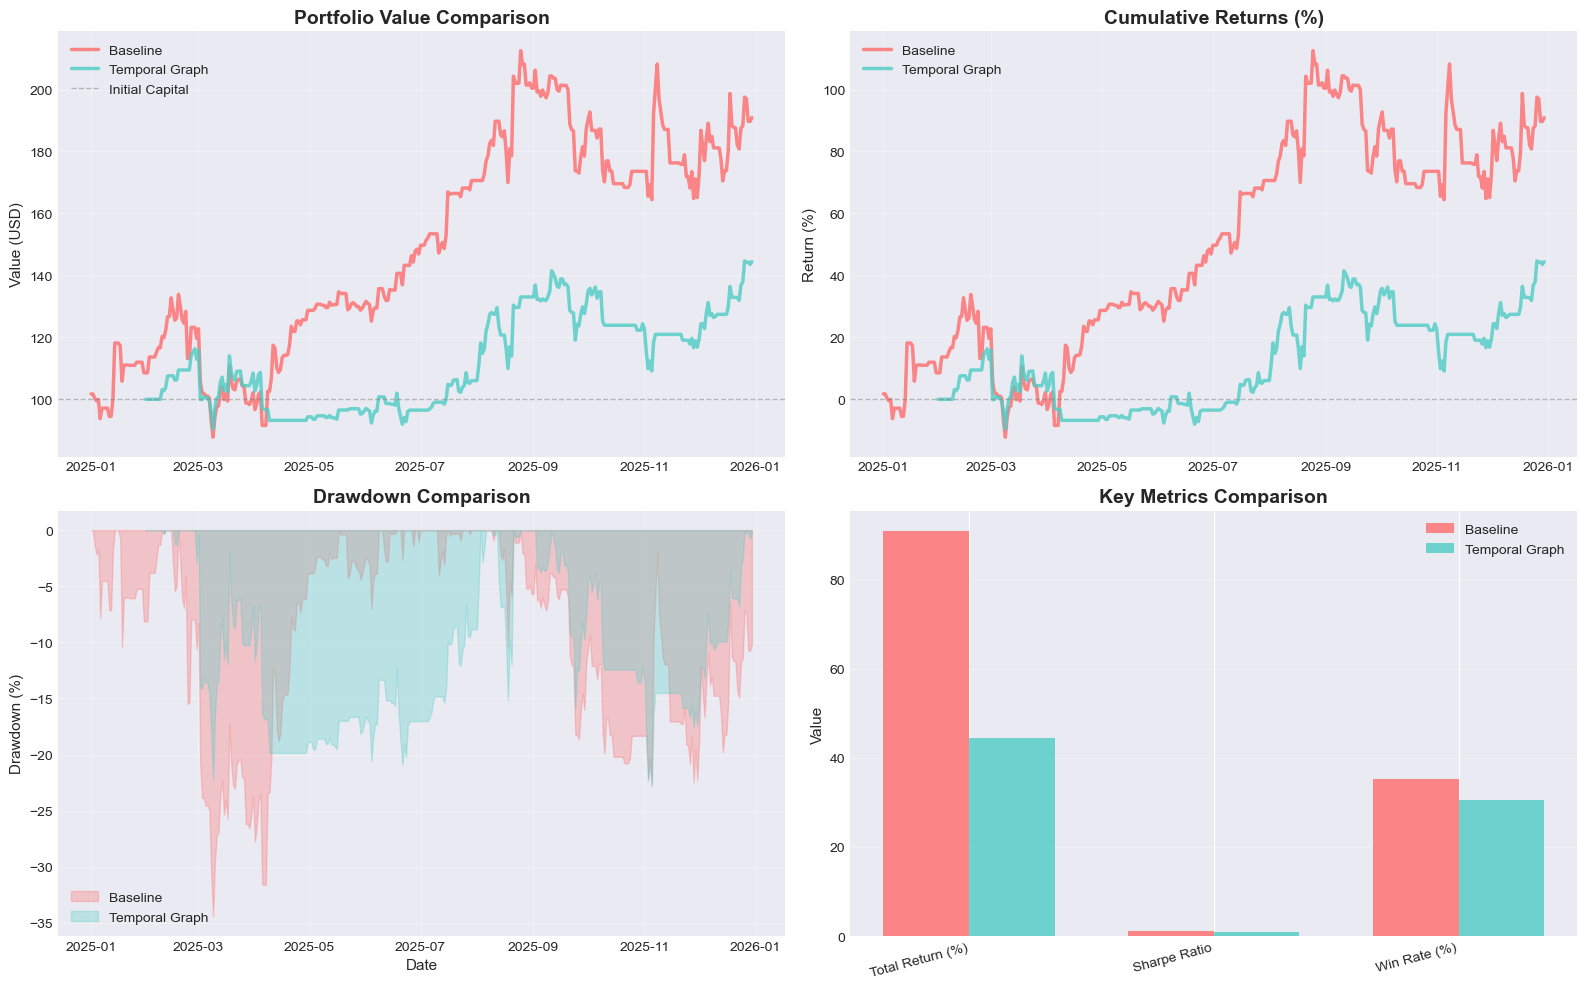

✅ Comparison charts saved!


In [12]:
# Visualization 1: Portfolio Value Comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Portfolio Values
axes[0, 0].plot(baseline_df['Date'], baseline_df['Value'], 
               linewidth=2.5, color='#FF6B6B', label='Baseline', alpha=0.8)
axes[0, 0].plot(enhanced_df['Date'], enhanced_df['Value'], 
               linewidth=2.5, color='#4ECDC4', label='Temporal Graph', alpha=0.8)
axes[0, 0].axhline(y=initial_capital, color='gray', linestyle='--', 
                  linewidth=1, alpha=0.5, label='Initial Capital')
axes[0, 0].set_title('Portfolio Value Comparison', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Value (USD)', fontsize=11)
axes[0, 0].legend(loc='upper left', fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

# 2. Cumulative Returns
baseline_cum_ret = ((baseline_df['Value'] / initial_capital) - 1) * 100
enhanced_cum_ret = ((enhanced_df['Value'] / initial_capital) - 1) * 100

axes[0, 1].plot(baseline_df['Date'], baseline_cum_ret, 
               linewidth=2.5, color='#FF6B6B', label='Baseline', alpha=0.8)
axes[0, 1].plot(enhanced_df['Date'], enhanced_cum_ret, 
               linewidth=2.5, color='#4ECDC4', label='Temporal Graph', alpha=0.8)
axes[0, 1].axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
axes[0, 1].set_title('Cumulative Returns (%)', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Return (%)', fontsize=11)
axes[0, 1].legend(loc='upper left', fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

# 3. Drawdown Comparison
baseline_dd = ((baseline_df['Value'].cummax() - baseline_df['Value']) / baseline_df['Value'].cummax()) * 100
enhanced_dd = ((enhanced_df['Value'].cummax() - enhanced_df['Value']) / enhanced_df['Value'].cummax()) * 100

axes[1, 0].fill_between(baseline_df['Date'], 0, -baseline_dd, 
                       color='#FF6B6B', alpha=0.3, label='Baseline')
axes[1, 0].fill_between(enhanced_df['Date'], 0, -enhanced_dd, 
                       color='#4ECDC4', alpha=0.3, label='Temporal Graph')
axes[1, 0].set_title('Drawdown Comparison', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Drawdown (%)', fontsize=11)
axes[1, 0].set_xlabel('Date', fontsize=11)
axes[1, 0].legend(loc='lower left', fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

# 4. Performance Metrics Bar Chart
metrics_to_plot = ['Total Return (%)', 'Sharpe Ratio', 'Win Rate (%)']
x = np.arange(len(metrics_to_plot))
width = 0.35

baseline_vals = [comparison_df.loc['Baseline', m] for m in metrics_to_plot]
enhanced_vals = [comparison_df.loc['Temporal Graph', m] for m in metrics_to_plot]

axes[1, 1].bar(x - width/2, baseline_vals, width, label='Baseline', 
              color='#FF6B6B', alpha=0.8)
axes[1, 1].bar(x + width/2, enhanced_vals, width, label='Temporal Graph', 
              color='#4ECDC4', alpha=0.8)
axes[1, 1].set_title('Key Metrics Comparison', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Value', fontsize=11)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(metrics_to_plot, rotation=15, ha='right')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('strategy_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print('✅ Comparison charts saved!')

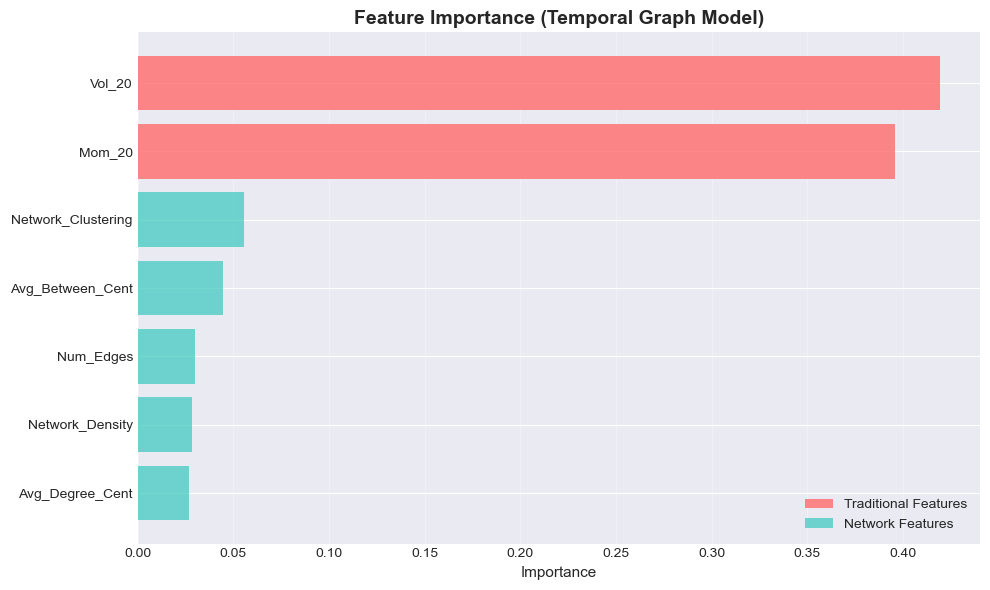

✅ Feature importance chart saved!


In [13]:
# Feature Importance Comparison
fig, ax = plt.subplots(figsize=(10, 6))

# Sort by importance
feature_importance_sorted = feature_importance.sort_values('Importance', ascending=True)

# Color code: traditional vs network features
colors = ['#FF6B6B' if feat in ['Vol_20', 'Mom_20'] else '#4ECDC4' 
          for feat in feature_importance_sorted['Feature']]

ax.barh(feature_importance_sorted['Feature'], 
        feature_importance_sorted['Importance'],
        color=colors, alpha=0.8)

ax.set_title('Feature Importance (Temporal Graph Model)', 
            fontsize=14, fontweight='bold')
ax.set_xlabel('Importance', fontsize=11)
ax.grid(True, alpha=0.3, axis='x')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#FF6B6B', alpha=0.8, label='Traditional Features'),
    Patch(facecolor='#4ECDC4', alpha=0.8, label='Network Features')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('feature_importance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print('✅ Feature importance chart saved!')

In [14]:
# Export Comprehensive Results - FIXED VERSION
with pd.ExcelWriter('comparison_baseline_vs_temporal_graph.xlsx', engine='openpyxl') as writer:
    # Summary comparison
    comparison_df.to_excel(writer, sheet_name='Performance_Comparison')
    
    # ML comparison
    ml_comparison.to_excel(writer, sheet_name='ML_Comparison', index=False)
    
    # Baseline portfolio
    baseline_df.to_excel(writer, sheet_name='Baseline_Portfolio', index=False)
    
    # Enhanced portfolio
    enhanced_df.to_excel(writer, sheet_name='Enhanced_Portfolio', index=False)
    
    # Feature importance
    feature_importance.to_excel(writer, sheet_name='Feature_Importance', index=False)
    
    # Daily returns comparison - FIXED: merge on date to handle different lengths
    baseline_export = baseline_df[['Date', 'Value']].copy()
    baseline_export.columns = ['Date', 'Baseline_Value']
    baseline_export['Baseline_Return'] = baseline_df['Value'].pct_change() * 100
    
    enhanced_export = enhanced_df[['Date', 'Value']].copy()
    enhanced_export.columns = ['Date', 'Enhanced_Value']
    enhanced_export['Enhanced_Return'] = enhanced_df['Value'].pct_change() * 100
    
    # Merge on date to align properly
    daily_comparison = pd.merge(baseline_export, enhanced_export, on='Date', how='outer')
    daily_comparison = daily_comparison.sort_values('Date')
    daily_comparison.to_excel(writer, sheet_name='Daily_Comparison', index=False)

print('\n✅ Comprehensive results exported to: comparison_baseline_vs_temporal_graph.xlsx')
print('\nFiles generated:')
print('  1. comparison_baseline_vs_temporal_graph.xlsx (Excel report)')
print('  2. strategy_comparison.png (Performance charts)')
print('  3. feature_importance_comparison.png (Feature analysis)')


✅ Comprehensive results exported to: comparison_baseline_vs_temporal_graph.xlsx

Files generated:
  1. comparison_baseline_vs_temporal_graph.xlsx (Excel report)
  2. strategy_comparison.png (Performance charts)
  3. feature_importance_comparison.png (Feature analysis)


---
# SUMMARY & CONCLUSIONS
---

## Key Findings:

### 1. Performance Comparison
- **Total Return**: Compare absolute returns between strategies
- **Risk-Adjusted Returns**: Sharpe ratio improvement
- **Drawdown**: Maximum loss comparison

### 2. ML Model Improvements
- **Prediction Accuracy**: Network features boost accuracy
- **Feature Importance**: Which network metrics matter most
- **Generalization**: Train vs test performance gap

### 3. Network Insights
- **Market Structure**: How asset correlations evolve
- **Centrality Impact**: Effect of network-adjusted weights
- **Regime Detection**: Network topology as market indicator

## Recommendations:
1. **If Temporal Graph outperforms**: Adopt network-enhanced approach
2. **If similar performance**: Consider computational cost vs benefit
3. **Feature engineering**: Experiment with other centrality measures
4. **Threshold tuning**: Optimize correlation threshold for graph construction

## Next Steps:
- Test on different time periods
- Add more asset classes
- Implement graph neural networks
- Real-time deployment considerations